# Element and Isotope Utilities

NEREIDS ships five element/isotope utility functions that bridge user-facing
strings like `"W-184"` and the numeric `(Z, A)` pairs required by the physics
engine.  They are thin wrappers around a compiled isotope table and return
instantly — no network calls.

The built-in table covers all **84 naturally-occurring elements** (Z = 1–92)
with IUPAC 2016 abundances, so `natural_isotopes(z)` works for every stable
element without any additional arguments.

## Functions covered

| Function | Input | Output |
|----------|-------|--------|
| `element_symbol(z)` | atomic number | symbol string (`"W"`) |
| `element_name(z)` | atomic number | full name (`"Tungsten"`) |
| `parse_isotope_str(s)` | `"W-184"` | `(74, 184)` tuple |
| `natural_isotopes(z)` | atomic number | list of `((Z, A), abundance)` |
| `natural_abundance(z, a)` | `(Z, A)` | fractional abundance or `None` |

## Prerequisites

```bash
pixi run build
```

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Element Queries

`element_symbol(z)` and `element_name(z)` convert an atomic number to the
standard symbol or full English name.  Useful when building axis labels or
result tables from a list of Z values.

In [2]:
for z in [1, 6, 26, 74, 92]:
    sym  = nereids.element_symbol(z)
    name = nereids.element_name(z)
    print(f"Z={z:3d}  symbol={sym:3s}  name={name}")

Z=  1  symbol=H    name=Hydrogen
Z=  6  symbol=C    name=Carbon
Z= 26  symbol=Fe   name=Iron
Z= 74  symbol=W    name=Tungsten
Z= 92  symbol=U    name=Uranium


## 2. Parsing Isotope Strings

`parse_isotope_str()` accepts the `"Symbol-A"` format (case-insensitive symbol,
hyphen separator, decimal mass number) and returns a `(Z, A)` integer tuple.
The hyphen is required — `"H1"` returns `None` while `"H-1"` works.
Returns `None` for unrecognised input.

In [3]:
isotopes_to_parse = ["W-184", "Fe-56", "U-235", "U-238", "Pu-241", "H-1"]

for s in isotopes_to_parse:
    z, a = nereids.parse_isotope_str(s)
    sym  = nereids.element_symbol(z)
    abun = nereids.natural_abundance(z, a)
    abun_str = f"{abun:.4f}" if abun is not None else "None (artificial)"
    print(f"{s:8s}  →  Z={z:3d}, A={a:3d}  ({sym})  abundance={abun_str}")

W-184     →  Z= 74, A=184  (W)  abundance=0.3064
Fe-56     →  Z= 26, A= 56  (Fe)  abundance=0.9175
U-235     →  Z= 92, A=235  (U)  abundance=0.0072
U-238     →  Z= 92, A=238  (U)  abundance=0.9927
Pu-241    →  Z= 94, A=241  (Pu)  abundance=None (artificial)
H-1       →  Z=  1, A=  1  (H)  abundance=0.9999


## 3. Natural Isotopic Composition

`natural_isotopes(z)` returns every stable isotope of an element along with
its natural fractional abundance.  The abundances are IUPAC 2016 values and
sum to 1.0 within floating-point precision.

In [4]:
# Tungsten — used as a structural material in the VENUS sample environment
isotopes_w = nereids.natural_isotopes(74)

print("Tungsten (Z=74) isotopes:")
print(f"  {'Isotope':10s}  {'Abundance':>10s}")
for (z, a), abundance in isotopes_w:
    print(f"  W-{a:<7d}  {abundance:>10.4f}")

total = sum(ab for _, ab in isotopes_w)
print(f"  {'Total':10s}  {total:>10.4f}")

Tungsten (Z=74) isotopes:
  Isotope      Abundance
  W-180          0.0012
  W-182          0.2650
  W-183          0.1431
  W-184          0.3064
  W-186          0.2843
  Total           1.0000


In [5]:
# Iron — dominant component of steel samples
isotopes_fe = nereids.natural_isotopes(26)

print("Iron (Z=26) isotopes:")
for (z, a), abundance in isotopes_fe:
    print(f"  Fe-{a:<6d}  {abundance:.4f}")

Iron (Z=26) isotopes:
  Fe-54      0.0585
  Fe-56      0.9175
  Fe-57      0.0212
  Fe-58      0.0028


## 4. Visualising Isotopic Compositions

A bar chart of isotopic abundances is a quick sanity check before setting up
a multi-isotope transmission model.

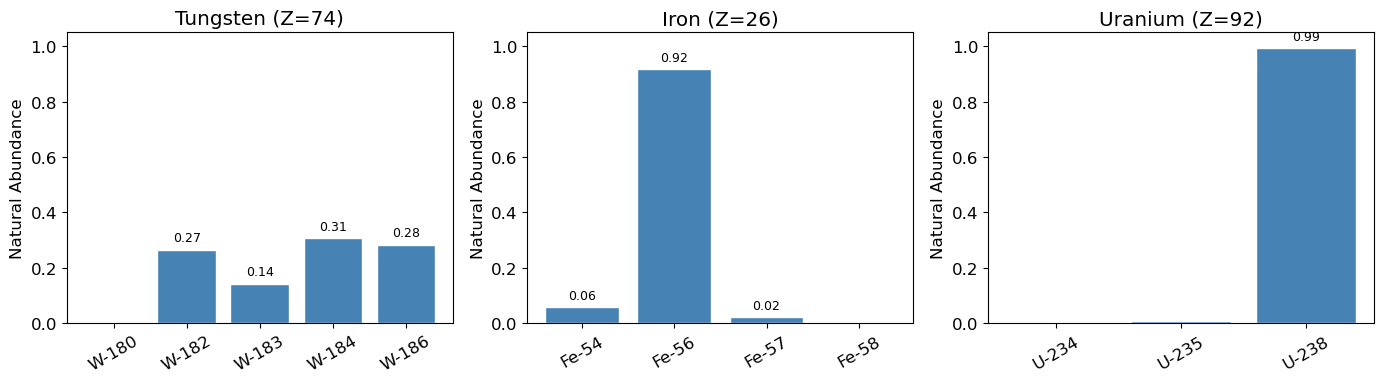

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

elements = [
    (74, "Tungsten"),
    (26, "Iron"),
    (92, "Uranium"),
]

for ax, (z, title) in zip(axes, elements):
    isotopes = nereids.natural_isotopes(z)
    labels   = [f"{nereids.element_symbol(z)}-{a}" for (_, a), _ in isotopes]
    values   = [ab for _, ab in isotopes]

    bars = ax.bar(labels, values, color='steelblue', edgecolor='white')
    ax.set_title(f"{title} (Z={z})")
    ax.set_ylabel("Natural Abundance")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)

    # Annotate bars > 1 %
    for bar, val in zip(bars, values):
        if val > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                    f"{val:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Specific Abundance Lookup

`natural_abundance(z, a)` returns the fractional abundance of a single isotope.
Returns `None` for artificially produced isotopes with no natural occurrence
(e.g. Pu-241).

In [7]:
queries = [
    (74, 184, "W-184"),
    (92, 235, "U-235"),
    (92, 238, "U-238"),
    (94, 241, "Pu-241"),  # artificially produced → None
    (26,  56, "Fe-56"),
]

for z, a, label in queries:
    ab = nereids.natural_abundance(z, a)
    if ab is None:
        print(f"{label:8s}  abundance = None  (artificially produced)")
    else:
        print(f"{label:8s}  abundance = {ab:.6f}")

W-184     abundance = 0.306400
U-235     abundance = 0.007204
U-238     abundance = 0.992742
Pu-241    abundance = None  (artificially produced)
Fe-56     abundance = 0.917540


## 6. Practical Use: Expanding an Element to an Isotope List

A common workflow: the user specifies a natural-abundance element by symbol,
and the code expands it into individual `(ResonanceData, areal_density)` pairs
for the multi-isotope transmission model.  Each isotope's areal density is the
element density multiplied by its natural abundance.

Here we build the tungsten transmission spectrum from natural W.

In [8]:
# Total areal density of natural tungsten (atoms/barn = atoms/cm² × 1e-24)
# A 1 mm plate of W (ρ=19.3 g/cm³, M=183.84 g/mol):
#   n = ρ × t × N_A / M = 19.3×0.1×6.022e23/183.84 ≈ 6.32e21 atoms/cm²
#   n_b = 6.32e21 × 1e-24 = 6.32e-3 atoms/barn
n_W_total = 6.32e-3  # atoms/barn

# Expand natural W into individual isotopes
components = []
for (z, a), abundance in nereids.natural_isotopes(74):
    data = nereids.load_endf(z, a)
    n_isotope = n_W_total * abundance
    components.append((data, n_isotope))
    print(f"  W-{a:3d}  abundance={abundance:.4f}  n={n_isotope:.4e} atoms/barn")

print(f"\nLoaded {len(components)} isotopes")

  W-180  abundance=0.0012  n=7.5840e-06 atoms/barn
  W-182  abundance=0.2650  n=1.6748e-03 atoms/barn
  W-183  abundance=0.1431  n=9.0439e-04 atoms/barn
  W-184  abundance=0.3064  n=1.9364e-03 atoms/barn
  W-186  abundance=0.2843  n=1.7968e-03 atoms/barn

Loaded 5 isotopes


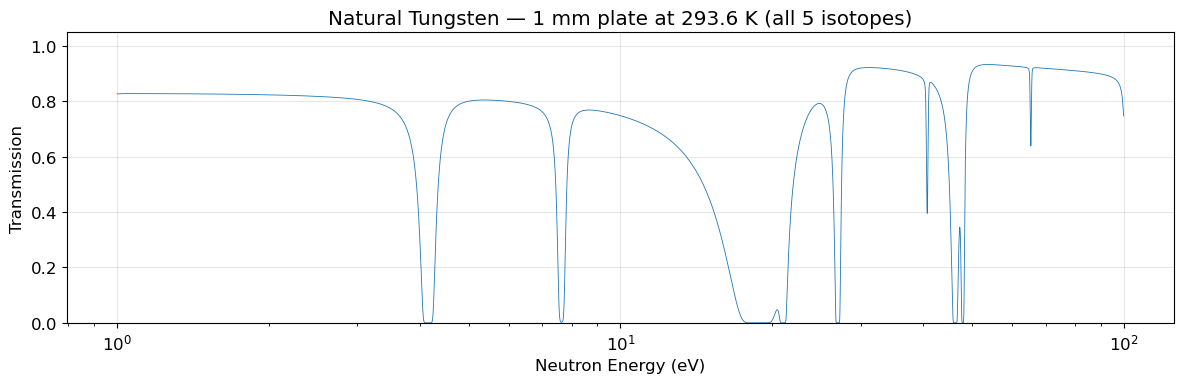

In [9]:
# Compute natural-W transmission at 293.6 K
energies = np.geomspace(1.0, 100.0, 8000)
T_nat_W = nereids.forward_model(energies, components, temperature_k=293.6)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(energies, T_nat_W, linewidth=0.6)
ax.set_xlabel("Neutron Energy (eV)")
ax.set_ylabel("Transmission")
ax.set_title("Natural Tungsten — 1 mm plate at 293.6 K (all 5 isotopes)")
ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Each dip corresponds to a neutron resonance in one of the five tungsten isotopes.
The depth of each dip is proportional to the isotope's areal density — dominated
by W-184 (30.6%) and W-186 (28.4%).

## Summary

| Function | Use case |
|----------|----------|
| `element_symbol(z)` | Build axis labels and print statements from Z |
| `element_name(z)` | Human-readable names for tables and reports |
| `parse_isotope_str(s)` | Convert user-facing strings ("W-184") to numeric (Z, A) |
| `natural_isotopes(z)` | Expand a natural element into weighted isotope components |
| `natural_abundance(z, a)` | Query single-isotope abundance for weighting |

**Next**: [03_spectrum_fitting.ipynb](03_spectrum_fitting.ipynb) — fitting a
measured transmission spectrum to recover isotopic areal densities.